# Model Training: Language Classification (CNN)

The goal of this notebook is to train a convolutional neural network (CNN) to classify spoken language based on Mel Spectrogram representations.

We use three classes:
- Polish (pl)
- Portuguese (pt)
- English (en)

Steps:
1. Load processed dataset
2. Split into training and test sets
3. Train CNN model
4. Evaluate performance

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from src.data.loader import LanguageDataset
from src.model.cnn import CNNModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Load Dataset

In [3]:
dataset = LanguageDataset("../data/processed")

print("Dataset size:", len(dataset))

Dataset size: 490


## 2. Train / Test Split

In [4]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 392
Test size: 98


## 3. Data Loaders

In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

## 4. Model Setup

In [6]:
model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=11264, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


## 5. Training Loop

In [7]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 0.9287
Epoch 2/10, Loss: 0.3910
Epoch 3/10, Loss: 0.1943
Epoch 4/10, Loss: 0.0775
Epoch 5/10, Loss: 0.0321
Epoch 6/10, Loss: 0.0375
Epoch 7/10, Loss: 0.0202
Epoch 8/10, Loss: 0.0053
Epoch 9/10, Loss: 0.0017
Epoch 10/10, Loss: 0.0008


## 6. Evaluation

In [8]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        outputs = model(x)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 96.94%


## 7. Confusion Matrix

To better understand model performance, we compute the confusion matrix.

This allows us to analyze how often each language is correctly classified and where the model makes mistakes.

In [9]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = model(x)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

In [10]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[23  0  0]
 [ 0 34  1]
 [ 1  1 38]]


## 8. Confusion Matrix Visualization

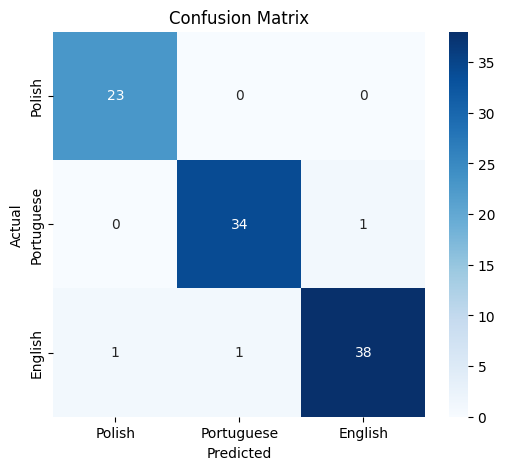

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Polish", "Portuguese", "English"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model performs very well across all three languages.

- Polish is classified perfectly with no errors.
- Portuguese has only one misclassification, confused with English.
- English has two minor misclassifications, once as Polish and once as Portuguese.

Overall, the model achieves high accuracy with very few errors, indicating strong generalization.

Most misclassifications occur between Portuguese and English, which may be due to similarities in phonetic and acoustic patterns.

This confirms that the CNN model effectively captures language-specific features from Mel Spectrograms.

## 9. Final Conclusions

In this project, a complete pipeline for language classification from speech was developed.

### Data Processing
Audio recordings were preprocessed by extracting fixed-length (3-second) segments and converting them into Mel Spectrogram representations. This ensured consistent input size and preserved relevant acoustic features.

### Model Performance
A Convolutional Neural Network (CNN) was trained to classify three languages: Polish, Portuguese, and English.

- Training loss decreased rapidly, reaching near-zero values.
- Test accuracy achieved **96.94%**, indicating excellent performance.
- The confusion matrix showed that most predictions were correct, with only a few misclassifications.

### Generalization and Overfitting
Although the training loss suggests some degree of overfitting, the high test accuracy confirms that the model generalizes well to unseen data.

This is likely due to:
- effective feature representation (Mel Spectrograms),
- sufficient variability in the dataset,
- and a well-suited CNN architecture.

### Error Analysis
Most errors occurred between Portuguese and English, which may be attributed to similarities in phonetic and acoustic patterns.

Polish was classified with perfect accuracy, suggesting that its acoustic characteristics are more distinct in the dataset.

### Final Assessment
The results demonstrate that:
- Mel Spectrograms are highly effective features for speech-based classification,
- CNN models can successfully learn language-specific patterns,
- even a relatively simple architecture can achieve high accuracy on this task.

---

### Future Improvements

Potential improvements to the model include:
- increasing dataset size,
- applying data augmentation (e.g., noise, pitch shift),
- adding regularization techniques (e.g., dropout),
- experimenting with deeper architectures.

---

## Key Result

The model achieved **96.94% accuracy** in classifying spoken language, demonstrating the effectiveness of CNNs and Mel Spectrogram features for speech-based tasks.

### Summary

The project successfully demonstrates a working end-to-end machine learning pipeline for language recognition from speech, achieving high accuracy and strong performance.